## Financial Data Cuantitative Analysis

- Retornos Logarítmicos.
- Estadísitcas descriptivas de distribucion de Retornos. 
- Hechos estilizados.
- Detrended Fluctuation Analysis.
- Movimiento Browniano Fraccionario.

In [1]:
import torch
print(torch.cuda.is_available())

True


In [2]:
print(torch.__version__)

2.3.0+cu121


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [4]:
tensor = torch.tensor([1, 2, 3])
print(tensor, tensor.device)

# Move tensor to GPU (if available)
tensor_on_gpu = tensor.to(device)
tensor_on_gpu

tensor([1, 2, 3]) cpu


tensor([1, 2, 3], device='cuda:0')

[*********************100%%**********************]  1 of 1 completed

                   Close  Log Returns
Date                                 
2008-10-02  24027.349609    -0.044365
2008-10-03  22989.500000    -0.044155
2008-10-06  21749.130859    -0.055464
2008-10-07  20884.740234    -0.040555
2008-10-08  20678.970703    -0.009901
...                  ...          ...
2024-06-10  53122.578125     0.002738
2024-06-11  53134.058594     0.000216
2024-06-12  52975.890625    -0.002981
2024-06-13  52275.648438    -0.013306
2024-06-14  52222.941406    -0.001009

[3937 rows x 2 columns]


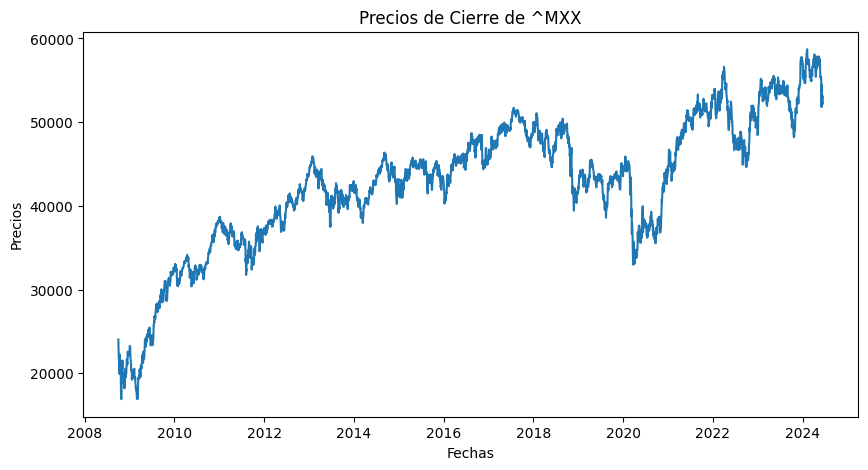

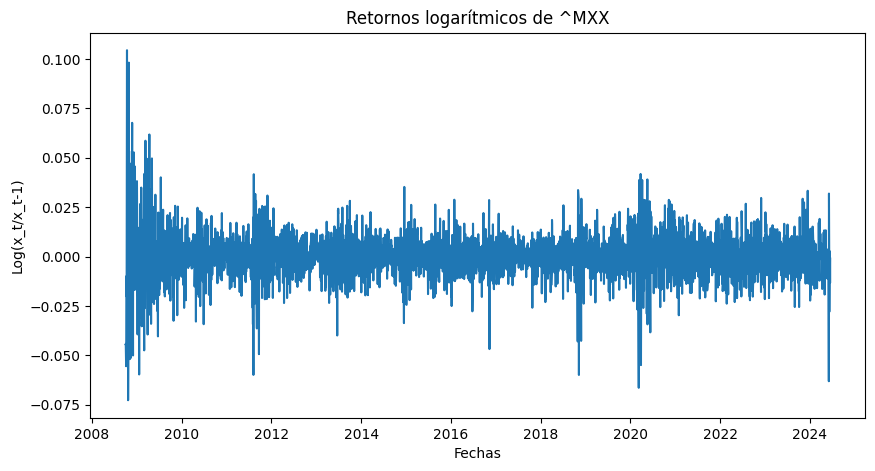

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import yfinance as yf
import numpy as np

def get_stock_data(ticker, start_date, end_date):
    stock_data = yf.download(ticker, start=start_date, end=end_date)
    return stock_data['Close']

# Función para calcular rendimientos logarítmicos
def calculate_log_returns(prices):
    return np.log(prices / prices.shift(1))#.dropna()

ticker = '^MXX'  # Cambiar el ticker según la acción que se desee analizar
start_date = '2008-10-01'
end_date = '2024-06-16'

# Obtener datos de Yahoo Finance
stock_data = get_stock_data(ticker, start_date, end_date)
#stock_data.head()
df = pd.DataFrame(stock_data)
df['Log Returns'] = calculate_log_returns(df['Close'])
df = df.dropna()
# Crear un objeto de Series de Pandas
#stock_data = pd.Series(stock_data)
print(df)

plt.figure(figsize=(10,5))
plt.plot(df['Close'])
plt.title(f'Precios de Cierre de {ticker}')
plt.xlabel('Fechas')
plt.ylabel('Precios')
plt.show()

plt.figure(figsize=(10,5))
plt.plot(df['Log Returns'])
plt.title(f'Retornos logarítmicos de {ticker}')
plt.xlabel('Fechas')
plt.ylabel('Log(x_t/x_t-1)')
plt.show()



In [10]:
# Calcular la media en cada segmento
def grafica_media_segmentos(df, num_segments, segment_length):
    segment_means = []
    for i in range(num_segments):
        segment = df[i*segment_length:(i+1)*segment_length]
        segment_mean = segment.mean()
        segment_means.append(segment_mean)
        print(f'Segmento {i+1} - Media: {segment_mean}')

# Graficar las medias de los segmentos
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, num_segments + 1), segment_means, marker='o')
    plt.title('Media de los Segmentos de los retornos logaritmicos del IPC')
    #plt.ylim(-.01,.01)
    plt.xlabel('Segmento')
    plt.ylabel('Media')
    plt.show()
    return segment_means

Segmento 1 - Media: 26044.109504214375
Segmento 2 - Media: 34910.148899689884
Segmento 3 - Media: 40479.43015465967
Segmento 4 - Media: 42045.77655852417
Segmento 5 - Media: 44352.79792859415
Segmento 6 - Media: 48504.090837706746
Segmento 7 - Media: 44894.27621063931
Segmento 8 - Media: 41211.05325620229
Segmento 9 - Media: 50430.21389949109
Segmento 10 - Media: 53900.98025007952


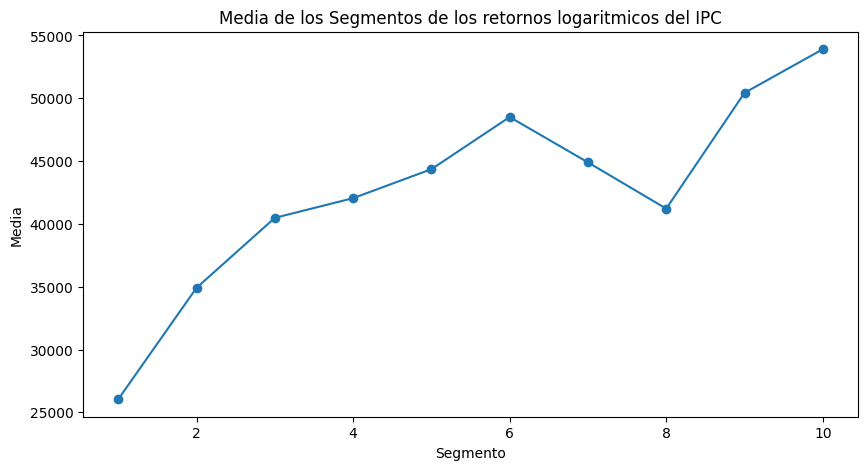

Segmento 1 - Media: 0.0006837885084744188
Segmento 2 - Media: 0.0002521522111835131
Segmento 3 - Media: 8.504167748761366e-05
Segmento 4 - Media: 0.00027216209599228064
Segmento 5 - Media: 0.000372865779412812
Segmento 6 - Media: -2.4186117830954634e-05
Segmento 7 - Media: -0.0002822190113422121
Segmento 8 - Media: 0.0003368553553351095
Segmento 9 - Media: 8.298336426780624e-05
Segmento 10 - Media: 0.00018747650563913864


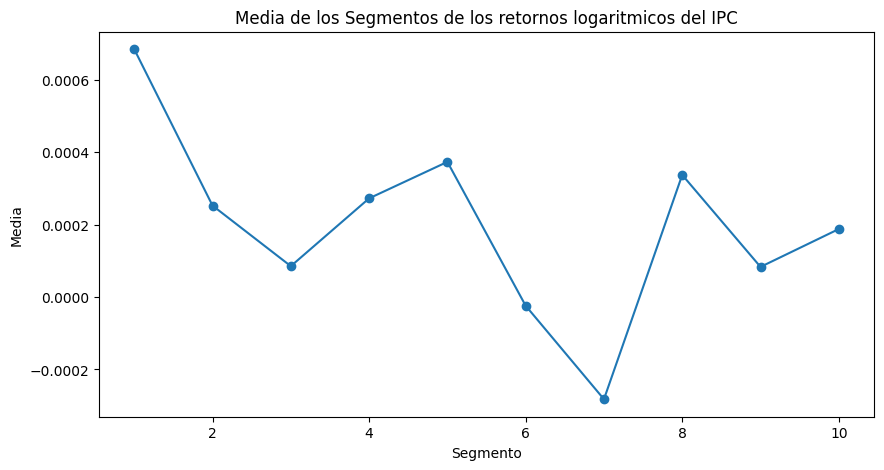

[0.0006837885084744188,
 0.0002521522111835131,
 8.504167748761366e-05,
 0.00027216209599228064,
 0.000372865779412812,
 -2.4186117830954634e-05,
 -0.0002822190113422121,
 0.0003368553553351095,
 8.298336426780624e-05,
 0.00018747650563913864]

In [37]:
num_segments = 10
segment_length = len(df['Close']) // num_segments
grafica_media_segmentos(df['Close'], num_segments, segment_length)
grafica_media_segmentos(df['Log Returns'], num_segments, segment_length)

## Hechos estilizados

In [24]:
%pip install seaborn

   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   ---- ----------------------------------- 30.7/294.9 kB 1.3 MB/s eta 0:00:01
   ---- ----------------------------------- 30.7/294.9 kB 1.3 MB/s eta 0:00:01
   ---- ----------------------------------- 30.7/294.9 kB 1.3 MB/s eta 0:00:01
   ---- ----------------------------------- 30.7/294.9 kB 1.3 MB/s eta 0:00:01
   ---- ----------------------------------- 30.7/294.9 kB 1.3 MB/s eta 0:00:01
   -------- ------------------------------ 61.4/294.9 kB 204.8 kB/s eta 0:00:02
   --------------- ---------------------- 122.9/294.9 kB 379.3 kB/s eta 0:00:01
   ------------------ ------------------- 143.4/294.9 kB 425.3 kB/s eta 0:00:01
   -------------------------- ----------- 204.8/294.9 kB 497.6 kB/s eta 0:00:01
   -------------------------- ----------- 204.8/294.9 kB 497.6 kB/s eta 0:00:01
   ----------------------------- -------- 225.3/294.9 kB 491.0 kB/s eta 0:00:01
   ------------------------------- ------ 245.8/294.9 

Estadísticas descriptivas:
count    3952.000000
mean        0.000390
std         0.012586
min        -0.115887
25%        -0.004115
50%         0.000633
75%         0.005940
max         0.135577
Name: Log Returns, dtype: float64

Curtosis: 14.38387635641449
Asimetría: -0.31769098803795565


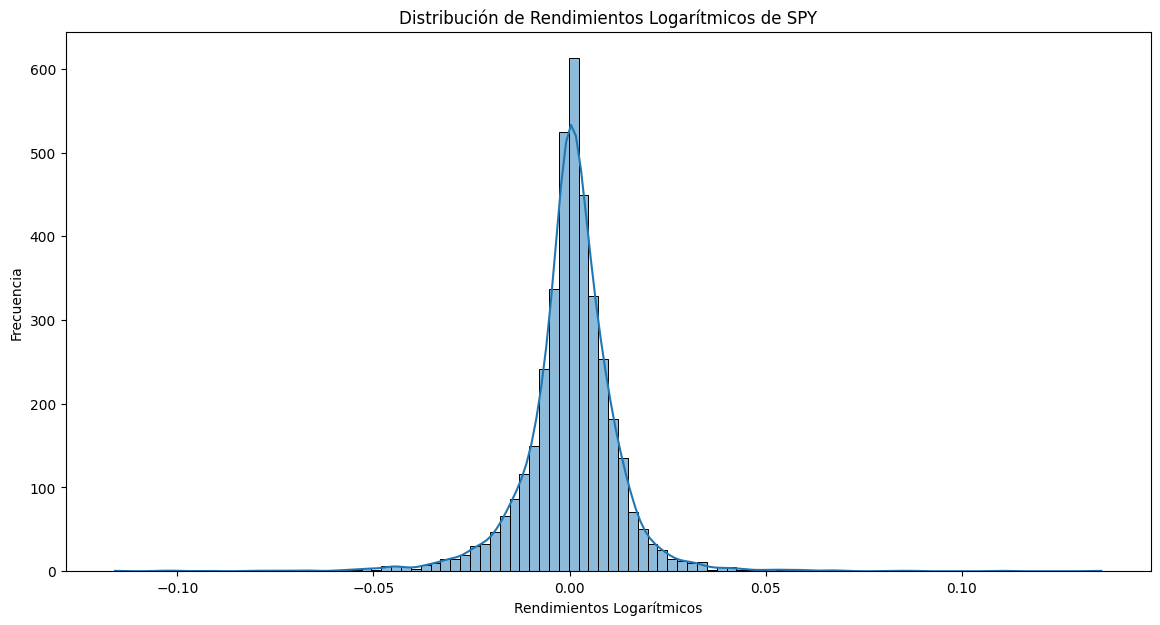

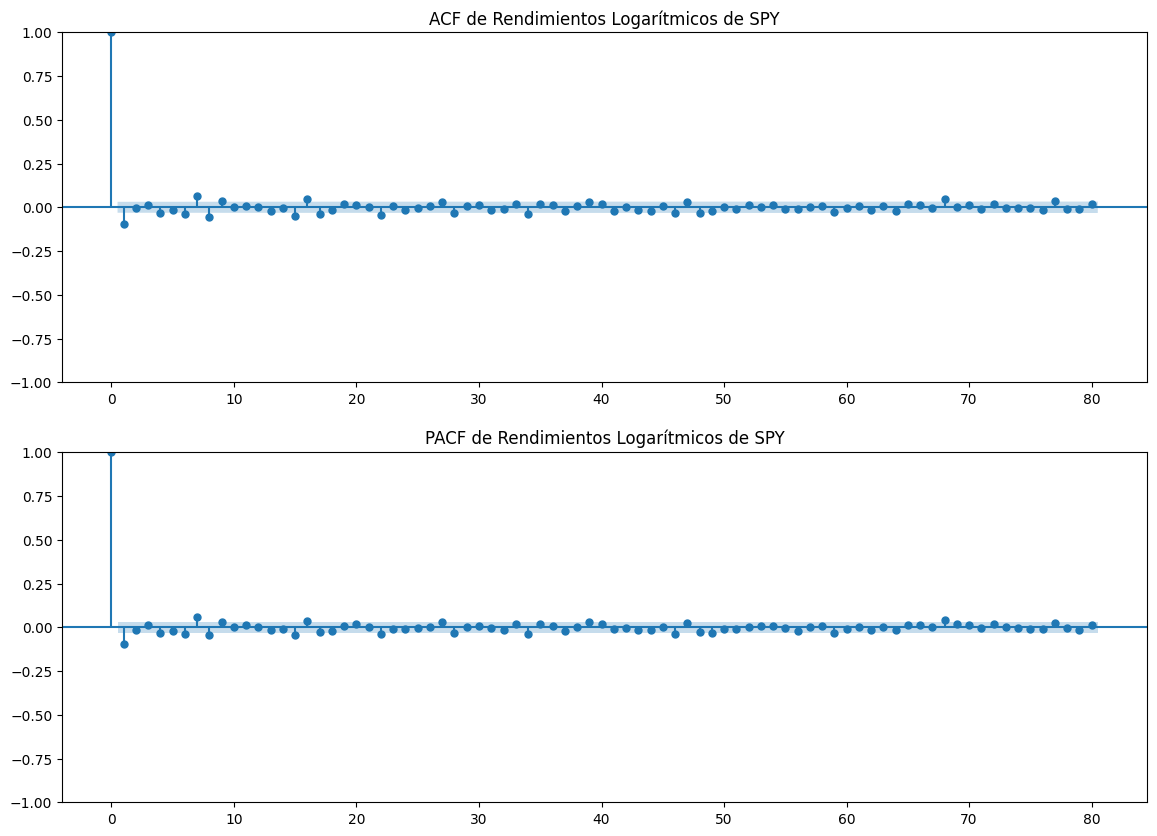

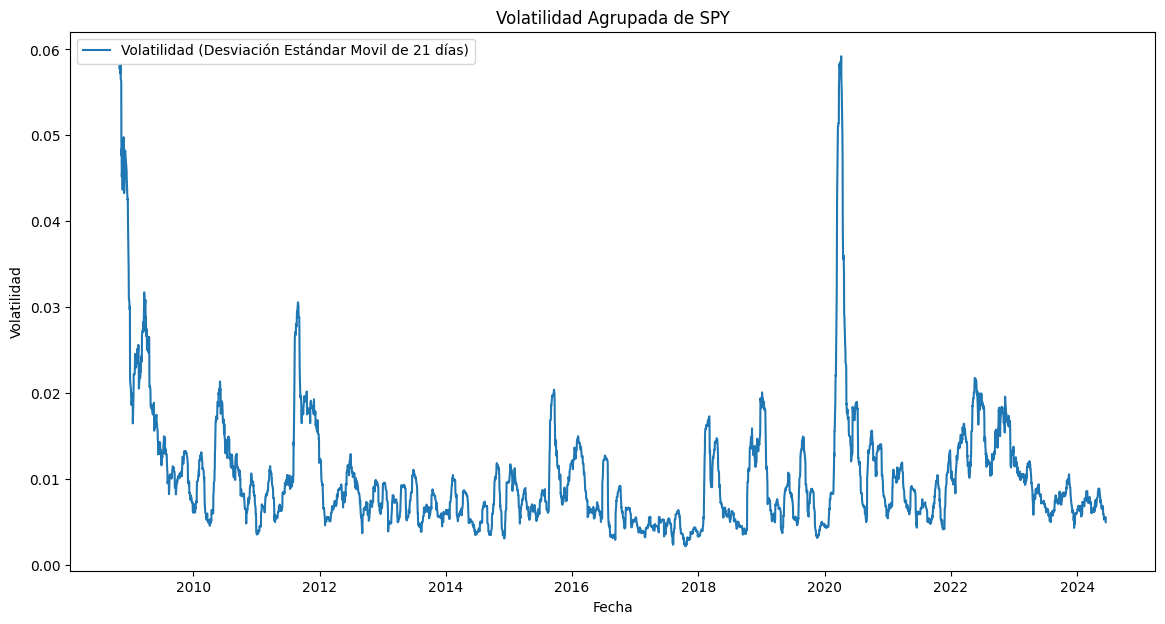

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import kurtosis, skew

# Función para calcular rendimientos logarítmicos
def calculate_log_returns(prices):
    return np.log(prices / prices.shift(1))

# Función para verificar y graficar hechos estilizados
def verify_stylized_facts(data,ticker):
    # Calcular rendimientos logarítmicos
    data = pd.DataFrame(data)
    data['Log Returns'] = calculate_log_returns(data['Close'])
    
    # Eliminar valores NaN
    data = data.dropna()
    
    # Estadísticas descriptivas
    print("Estadísticas descriptivas:")
    print(data['Log Returns'].describe())
    
    # Calcular curtosis y asimetría
    print("\nCurtosis:", kurtosis(data['Log Returns']))
    print("Asimetría:", skew(data['Log Returns']))
    
    # Graficar histograma de rendimientos logarítmicos
    plt.figure(figsize=(14, 7))
    sns.histplot(data['Log Returns'], bins=100, kde=True)
    plt.title(f'Distribución de Rendimientos Logarítmicos de {ticker}')
    plt.xlabel('Rendimientos Logarítmicos')
    plt.ylabel('Frecuencia')
    plt.show()
    
    # Graficar ACF y PACF de los rendimientos logarítmicos
    fig, ax = plt.subplots(2, 1, figsize=(14, 10))
    sm.graphics.tsa.plot_acf(data['Log Returns'], lags=80, ax=ax[0])
    sm.graphics.tsa.plot_pacf(data['Log Returns'], lags=80, ax=ax[1])
    ax[0].set_title(f'ACF de Rendimientos Logarítmicos de {ticker}')
    ax[1].set_title(f'PACF de Rendimientos Logarítmicos de {ticker}')
    plt.show()
    
    # Graficar volatilidad agrupada
    plt.figure(figsize=(14, 7))
    plt.plot(data['Log Returns'].rolling(window=21).std(), label='Volatilidad (Desviación Estándar Movil de 21 días)')
    plt.title(f'Volatilidad Agrupada de {ticker}')
    plt.xlabel('Fecha')
    plt.ylabel('Volatilidad')
    plt.legend()
    plt.show()

# Cargar datos de una serie de tiempo financiera (ejemplo: datos de precios de acciones)
#data = pd.read_csv('path_to_your_file.csv', parse_dates=True, index_col='Date')
# Definir el ticker, la fecha de inicio y fin
# Verificar y graficar hechos estilizados
verify_stylized_facts(stock_data, ticker)

## Detrended Fluctuation Analysis (DFA)

In [4]:
import numpy as np
import matplotlib.pyplot as plt


def detrended_fluctuation_analysis(y, n_vals):
    N = len(y)
    mean_y = np.mean(y)
    #center_y = y - mean_y
    Y = np.cumsum(y - mean_y)
    #plt.figure(figsize=(10,5))
    #plt.title(f'Serie de {ticker} centrada -> x(t)-media(x(t))')
    #plt.plot(center_y)
    #plt.show()
    plt.figure(figsize=(10,5))
    plt.title(f'Perfil de la serie {ticker} - Suma acomulativa')
    plt.plot(Y)
    plt.show()

    F = [] 
    for n in n_vals:
        segments = int(N / n)
        F_n_seg = []

        for i in range(segments):
            segment = Y[i * n:(i + 1) * n]
            t = np.arange(len(segment))
            poly = np.polyfit(t, segment, 1)
            trend = np.polyval(poly, t)
            detrended = segment - trend
            F_n_seg.append(np.sqrt(np.mean(detrended**2)))

        F.append(np.sqrt(np.mean(np.array(F_n_seg)**2)))
        #F.append(np.mean(F_n_seg))
    
    return np.array(F)


def grafica_alpha(n_vals,F, ticker):   
    # Convertir n_vals y F a logaritmos
    log_n_vals = np.log(n_vals)
    log_F = np.log(F)

    # Ajuste lineal en el espacio log-log
    coeffs = np.polyfit(log_n_vals, log_F, 1)
    print(coeffs)
    alpha = coeffs[0]  # La pendiente es el exponente α
    #intercept = coeffs[1]

    # Crear la recta ajustada para graficar
    fit_line = np.polyval(coeffs, log_n_vals)


    plt.loglog(n_vals, F, 'o-')
    plt.loglog(n_vals, np.exp(fit_line), '--', label=f'Ajuste lineal: alpha={alpha:.4f}')
    plt.xlabel('log(n)')
    plt.ylabel('log(F(n))')
    plt.title(f'Detrended Fluctuation Analysis (DFA-1°) para {ticker}')
    plt.legend()
    plt.axis('equal')
    plt.show()

    print(f"El exponente α es: {alpha:.4f}")

# Ejemplo de uso
# Definir el ticker, la fecha de inicio y fin
#ticker = 'MXN=X'  # Cambiar el ticker según la acción que se desee analizar
#start_date = '2020-10-01'
#end_date = '2024-06-06'

# Obtener datos de Yahoo Finance
#stock_data = get_stock_data(ticker, start_date, end_date)
# Asegura de que stock_data no contiene NaN o inf
#if np.any(np.isnan(stock_data)) or np.any(np.isinf(stock_data)):
#    raise ValueError("stock_data contiene valores NaN o inf")

'''
x = np.linspace(0, 10, 1000)
y = np.sin(57*x) + 5*np.sin(25*x) + 13*np.sin(3*x) + np.random.randn(1000)*.1 
plt.plot(x, y)
plt.show()

#time_series = np.random.randn(1000)  # Reemplazar con datos financieros reales
n_vals = np.logspace(1, 2, 30).astype(int)
F = detrended_fluctuation_analysis(stock_data, n_vals)
grafica_alpha(n_vals,F, ticker)
'''

'\nx = np.linspace(0, 10, 1000)\ny = np.sin(57*x) + 5*np.sin(25*x) + 13*np.sin(3*x) + np.random.randn(1000)*.1 \nplt.plot(x, y)\nplt.show()\n\n#time_series = np.random.randn(1000)  # Reemplazar con datos financieros reales\nn_vals = np.logspace(1, 2, 30).astype(int)\nF = detrended_fluctuation_analysis(stock_data, n_vals)\ngrafica_alpha(n_vals,F, ticker)\n'

## Movimiento Browniano fraccionario

In [46]:
%pip install fbm

Note: you may need to restart the kernel to use updated packages.


         Close
0     0.000000
1    -0.011942
2    -0.033929
3    -0.027936
4    -0.059974
...        ...
996  -0.634747
997  -0.616663
998  -0.633012
999  -0.652792
1000 -0.622361

[1001 rows x 1 columns]


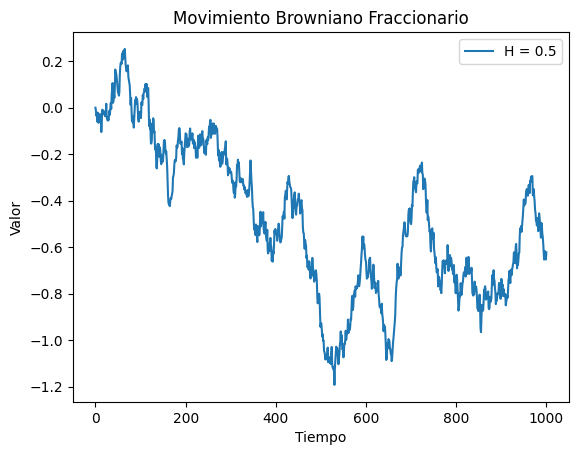

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fbm import FBM

def generate_fractional_brownian_motion(n, H):
    fbm = FBM(n=n, hurst=H, length=1, method='daviesharte')
    return fbm.fbm()

# Parámetros
n = 1000  # Longitud de la serie temporal
H = 0.5  # Exponente de Hurst

# Generar datos sintéticos de fBM
synthetic_data = generate_fractional_brownian_motion(n, H)
Sdata_df = pd.DataFrame(synthetic_data, columns=['Close'])
print(Sdata_df)
# Visualización
plt.plot(synthetic_data, label=f'H = {H}')
plt.title('Movimiento Browniano Fraccionario')
plt.xlabel('Tiempo')
plt.ylabel('Valor')
plt.legend()
plt.show()

Estadísticas descriptivas:
count    988.000000
mean            inf
std             NaN
min       -2.923915
25%       -0.042701
50%        0.001722
75%        0.047092
max             inf
Name: Log Returns, dtype: float64

Curtosis: nan
Asimetría: nan


c:\Users\marti\Documents\python\.venv\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\marti\Documents\python\.venv\lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\marti\Documents\python\.venv\lib\site-packages\scipy\stats\_stats_py.py:1054: RuntimeWarning: invalid value encountered in subtract
  a_zero_mean = a - mean


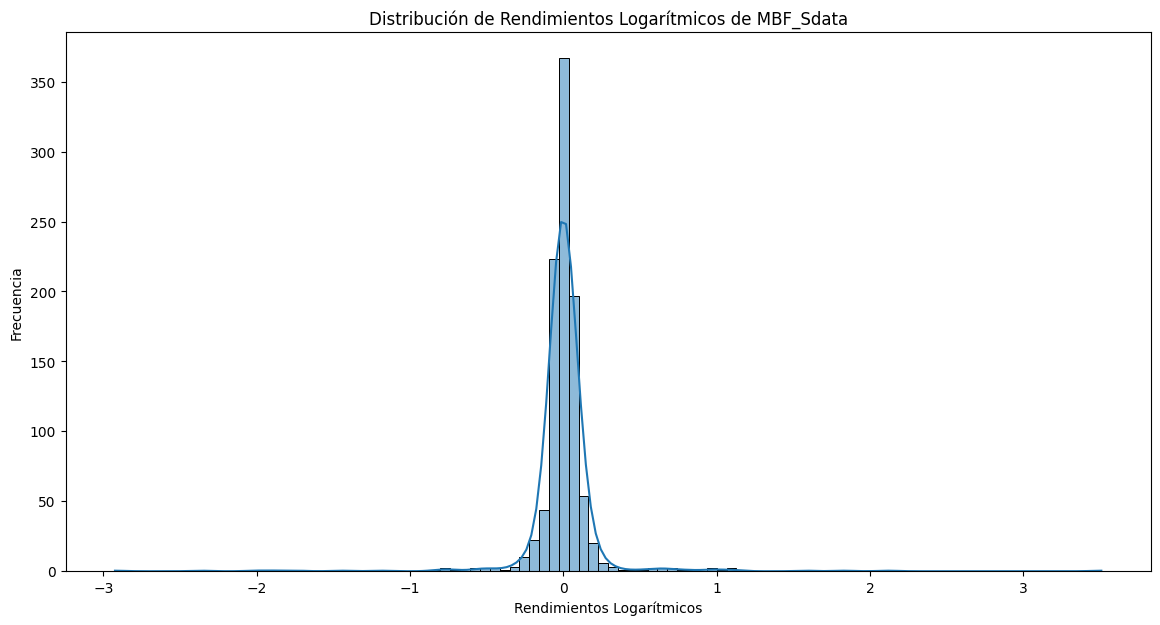

c:\Users\marti\Documents\python\.venv\lib\site-packages\statsmodels\tsa\stattools.py:472: RuntimeWarning: invalid value encountered in subtract
  xo = x - x.mean()
c:\Users\marti\Documents\python\.venv\lib\site-packages\statsmodels\regression\linear_model.py:1473: RuntimeWarning: invalid value encountered in subtract
  x -= x.mean()


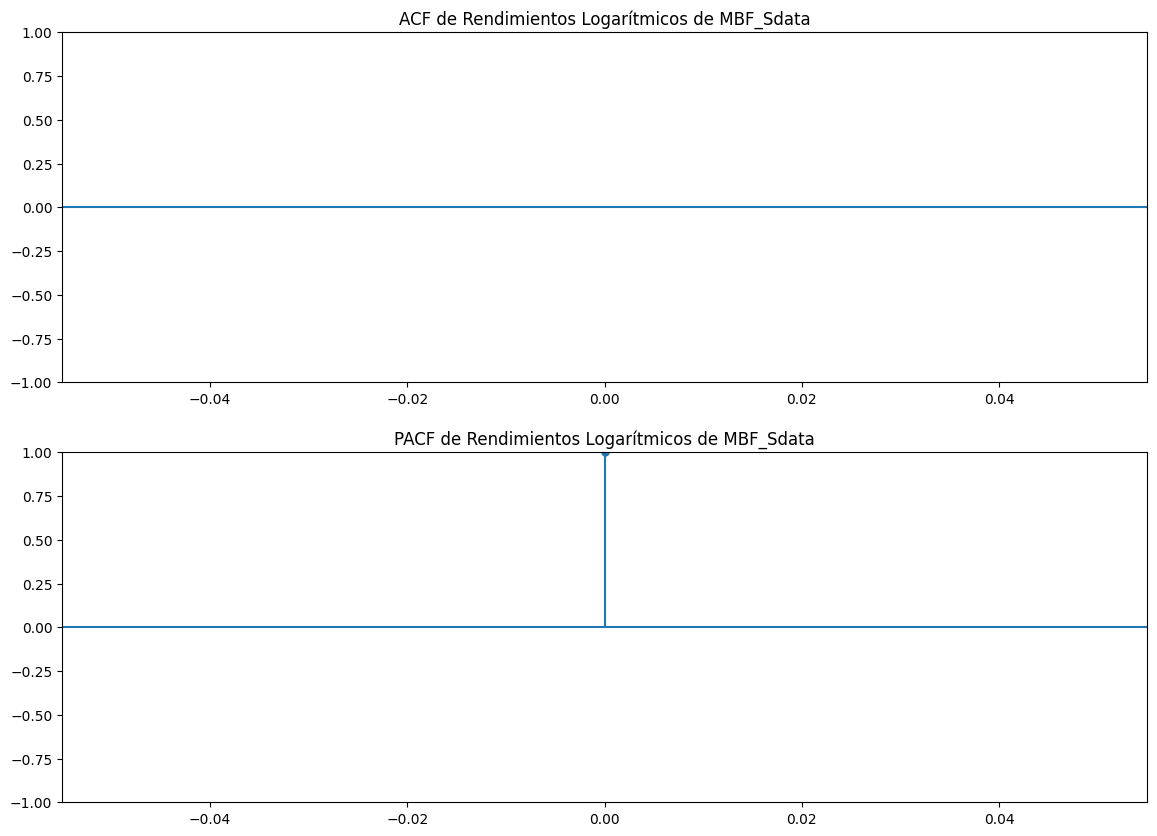

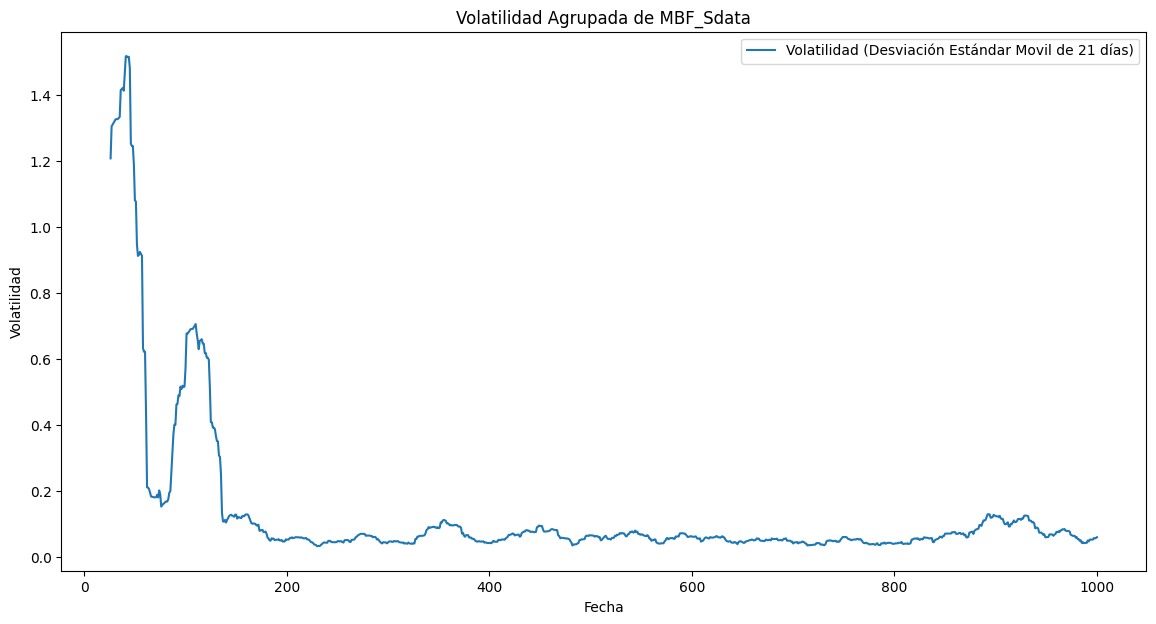

In [38]:

# Verificar y graficar hechos estilizados
verify_stylized_facts(Sdata_df, 'MBF_Sdata')

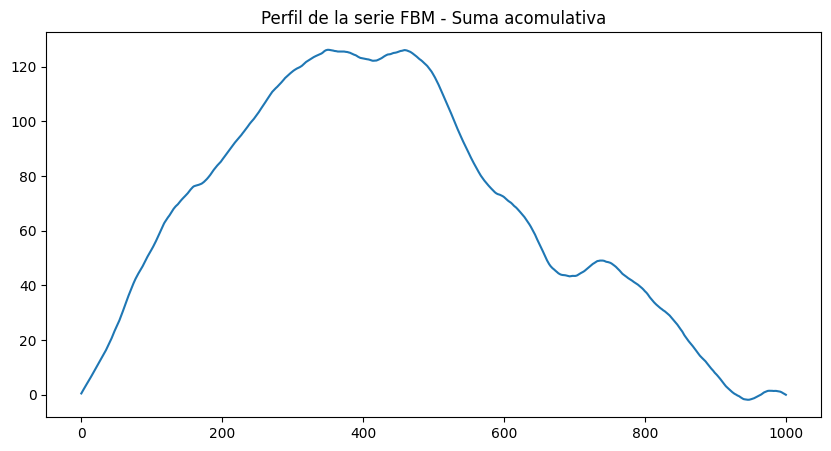

[ 1.54785873 -6.62094336]


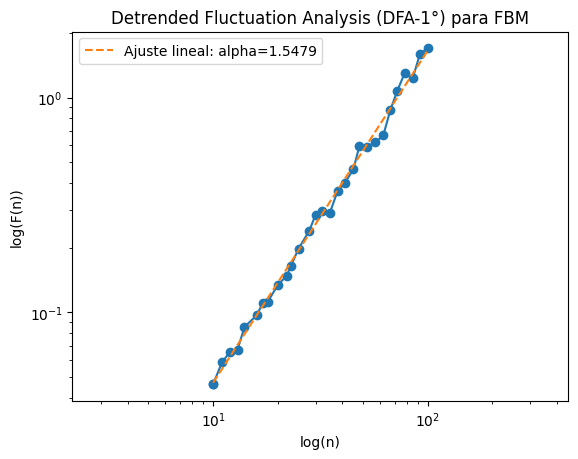

El exponente α es: 1.5479


In [14]:
n_vals = np.logspace(1, 2, 30).astype(int)
ticker= 'FBM'
F_MB = detrended_fluctuation_analysis(synthetic_data, n_vals)
grafica_alpha(n_vals, F_MB, ticker)

### Pruebas de Autocorrelación completa y parcial

Estadísticas descriptivas:
count    234.000000
mean       0.127028
std        1.660514
min       -5.221563
25%       -0.822635
50%        0.140699
75%        1.039042
max        5.509859
Name: Simple Time Series, dtype: float64


c:\Users\marti\Documents\python\.venv\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


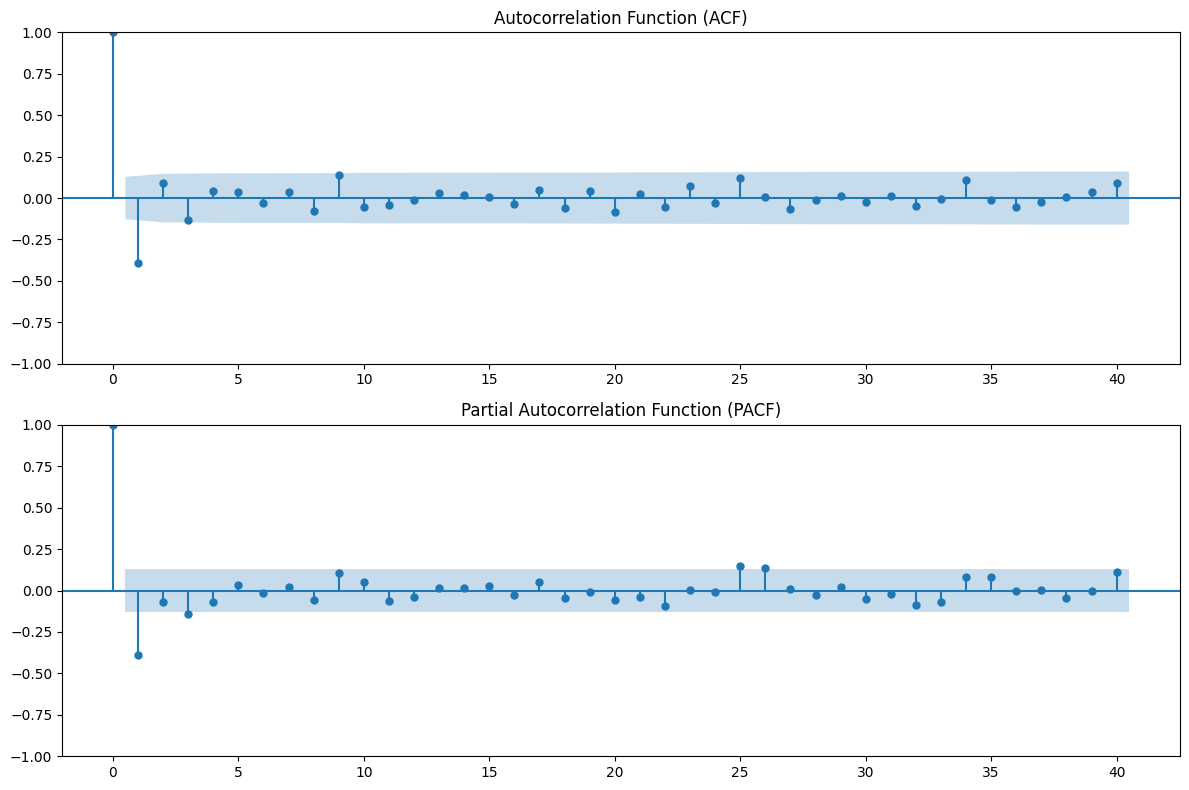

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Crear una serie de tiempo simple
np.random.seed(0)
data = pd.Series(np.random.normal(size=1000), name='Simple Time Series')

# Calcular los retornos logarítmicos
log_returns = np.log(data).diff().dropna()

# Visualizar las estadísticas descriptivas
print("Estadísticas descriptivas:")
print(log_returns.describe())

# Graficar ACF y PACF
fig, ax = plt.subplots(2, 1, figsize=(12, 8))

# Gráfica de ACF
sm.graphics.tsa.plot_acf(log_returns, lags=40, ax=ax[0])
ax[0].set_title('Autocorrelation Function (ACF)')

# Gráfica de PACF
sm.graphics.tsa.plot_pacf(log_returns, lags=40, ax=ax[1])
ax[1].set_title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()

## Generación de datos estacionarios a través de un proceso AutoRegresivo (AR(1))


Generar una serie de tiempo estacionaria implica crear datos cuya media, varianza y covarianza no cambian con el tiempo. Un proceso comúnmente utilizado para este propósito es el proceso autorregresivo de primer orden (AR(1)) con parámetros adecuados.

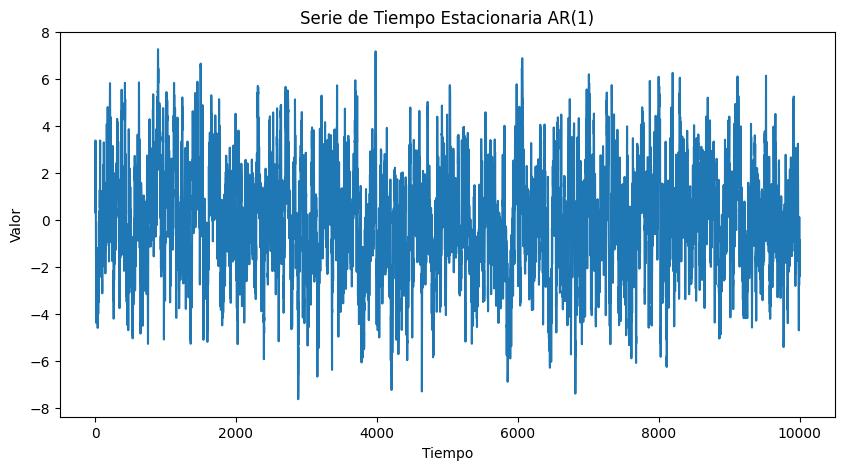

In [44]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros del modelo AR(1)
n = 10000 # número de puntos en la serie de tiempo
phi = 0.9  # coeficiente de autoregresión
sigma = 1  # desviación estándar del término de ruido
mu = 0  # media de la serie

# Generar ruido blanco
np.random.seed(42)
epsilon = np.random.normal(0, sigma, n)

# Inicializar la serie de tiempo
X = np.zeros(n)
X[0] = mu + epsilon[0]

# Generar la serie de tiempo AR(1)
for t in range(1, n):
    X[t] = mu + phi * (X[t-1] - mu) + epsilon[t]
    #X[t] = mu + epsilon[t]

# Graficar la serie de tiempo
plt.figure(figsize=(10, 5))
plt.plot(X)
plt.title('Serie de Tiempo Estacionaria AR(1)')
plt.xlabel('Tiempo')
plt.ylabel('Valor')
plt.show()

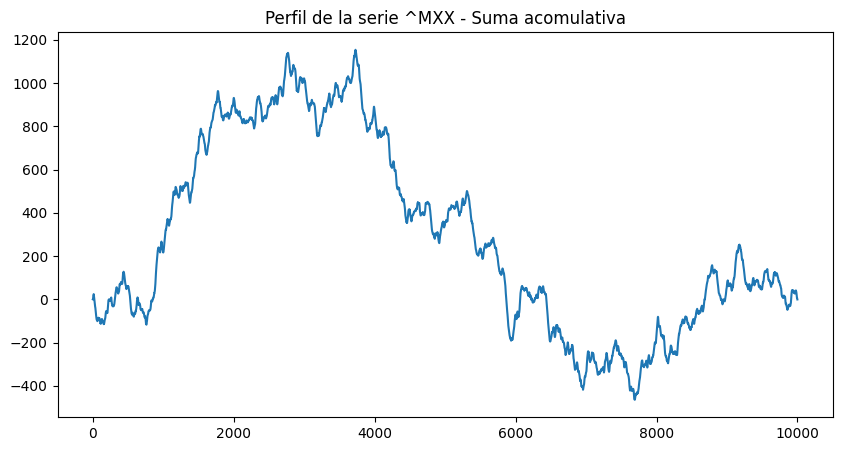

[ 1.0959668  -2.10346644]


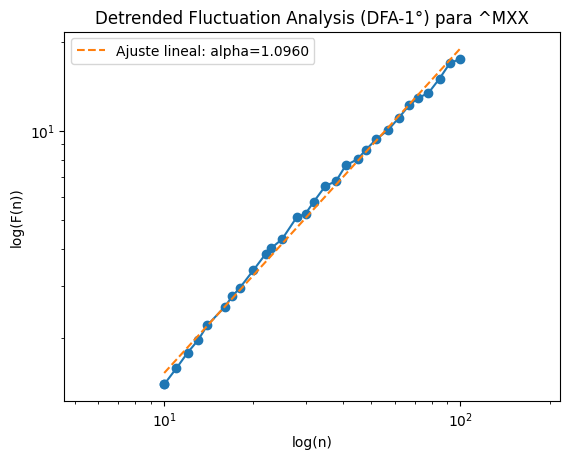

El exponente α es: 1.0960


In [45]:
AR1 = detrended_fluctuation_analysis(X, n_vals)
grafica_alpha(n_vals,AR1)

In [ ]:
# Calcular la media en cada segmento
def grafica_media_segmentos(df, num_segments, segment_length):
    segment_means = []
    for i in range(num_segments):
        segment = df[i*segment_length:(i+1)*segment_length]
        segment_mean = segment.mean()
        segment_means.append(segment_mean)
        print(f'Segmento {i+1} - Media: {segment_mean}')

# Graficar las medias de los segmentos
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, num_segments + 1), segment_means, marker='o')
    plt.title('Media de los Segmentos de la Serie Temporal')
    plt.ylim(-.01,.01)
    plt.xlabel('Segmento')
    plt.ylabel('Media')
    plt.show()
    return segment_means

Segmento 1 - Media: 0.44483187496874566
Segmento 2 - Media: -0.05095190637669748
Segmento 3 - Media: -0.49080959318140066
Segmento 4 - Media: -0.06879225912252498
Segmento 5 - Media: 0.06278396821060374


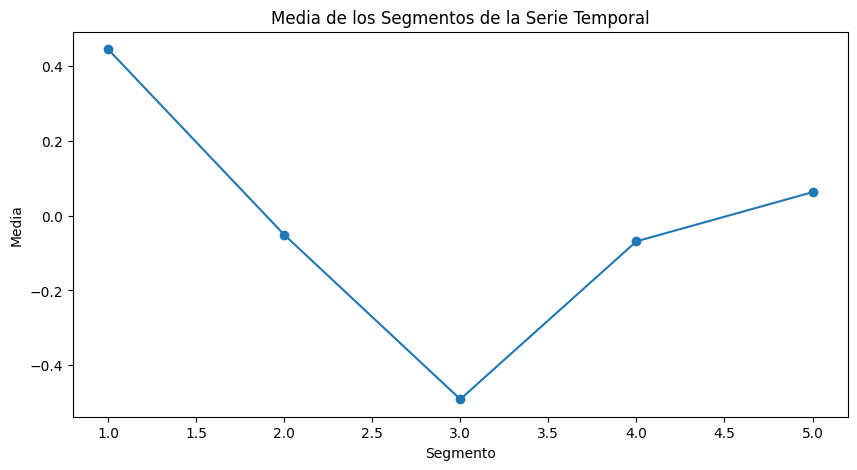

Promedio total -> -0.02058758310025478
Las medias de los segmentos varían significativamente de la media global.


In [59]:
import pandas as pd

# Crear un DataFrame para manejar la serie temporal
df = pd.DataFrame({'X_t': X})

# Dividir la serie temporal en segmentos
num_segments = 5
segment_length = len(df) // num_segments



segment_means = grafica_media_segmentos(df['X_t'], num_segments, segment_length)

# Verificar si las medias de los segmentos son aproximadamente iguales
overall_mean = df['X_t'].mean()
print(f'Promedio total -> {overall_mean}')
if np.allclose(segment_means, overall_mean, rtol=10):
    print("Las medias de los segmentos son aproximadamente iguales a la media global.")
else:
    print("Las medias de los segmentos varían significativamente de la media global.")


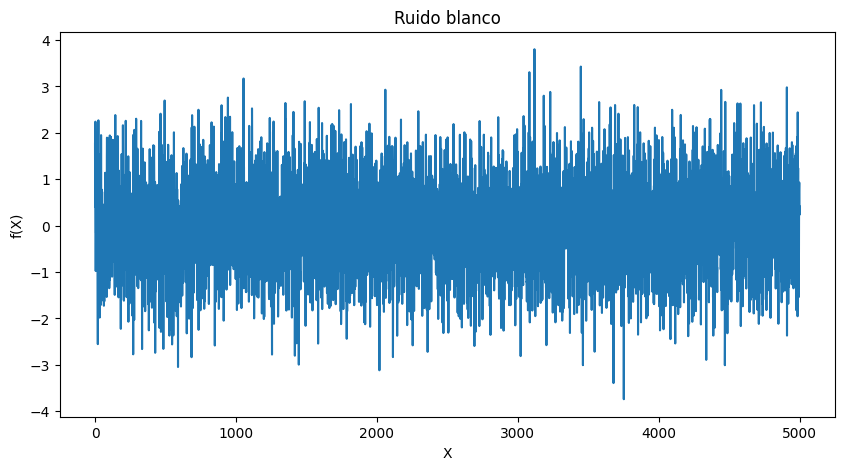

Segmento 1 - Media: X_t   -0.045257
dtype: float64
Segmento 2 - Media: X_t    0.013617
dtype: float64
Segmento 3 - Media: X_t   -0.051229
dtype: float64
Segmento 4 - Media: X_t   -0.018943
dtype: float64
Segmento 5 - Media: X_t    0.028181
dtype: float64


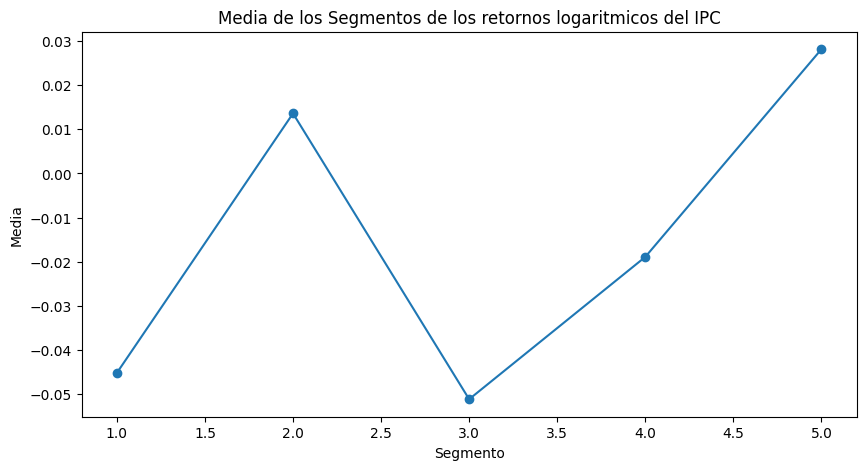

Promedio de los promedios por segmento -> -0.014726047025784056
Promedio total -> -0.014726047025784061
Las medias de los segmentos son aproximadamente iguales a la media global.


In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, acf

# Generar una serie temporal de ejemplo
np.random.seed(0)
n = 5000
mu = 0
sigma = 1
epsilon = np.random.normal(mu, sigma, n)
X_t = mu + epsilon

# Crear un DataFrame para manejar la serie temporal
df = pd.DataFrame({'X_t': X_t})

# Dividir la serie temporal en segmentos
num_segments = 5
segment_length = len(df) // num_segments


# Graficar las medias de los segmentos
plt.figure(figsize=(10, 5))
plt.plot(X_t)
#plt.plot(range(1, num_segments + 1), segment_means, marker='o')
plt.title('Ruido blanco')
plt.xlabel('X')
plt.ylabel('f(X)')
plt.show()

segment_means = grafica_media_segmentos(df, num_segments, segment_length)

# Verificar si las medias de los segmentos son aproximadamente iguales
overall_mean = df['X_t'].mean()
print(f'Promedio de los promedios por segmento -> {np.mean(segment_means)}')
print(f'Promedio total -> {overall_mean}')
if np.allclose(np.mean(segment_means), overall_mean, rtol=.1):
    print("Las medias de los segmentos son aproximadamente iguales a la media global.")
else:
    print("Las medias de los segmentos varían significativamente de la media global.")


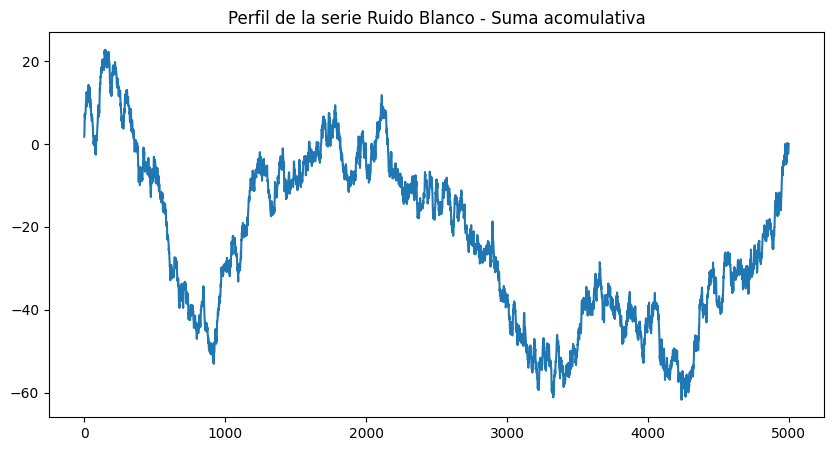

[ 0.4997693  -1.36797097]


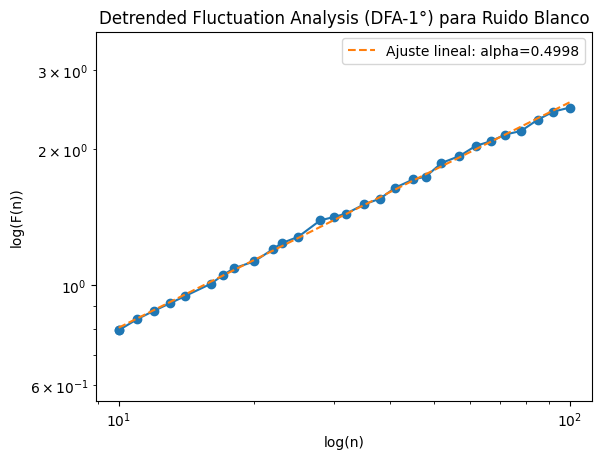

El exponente α es: 0.4998


In [52]:
RBlanco = detrended_fluctuation_analysis(X_t, n_vals)
ticker = 'Ruido Blanco'
grafica_alpha(n_vals,RBlanco,ticker )